# EDA: ingresos por día

Serie diaria construida a partir de pedidos: ingreso total, número de pedidos, día de la semana, mes, fin de semana, festivo (Venezuela con `holidays`), ticket medio, hora modal del día y placeholders de promoción/evento.

Bloques: agregación diaria, día de la semana, mes, fin de semana/festivo, serie y boxplot semanal, hora pico, correlaciones y CSV para el siguiente notebook.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
import warnings
import holidays

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

DATA_DIR = Path('data')


## 1. Agregación diaria

Una fila por `order_date` en `orders`: suma de `total`, conteo de pedidos, subtotal y delivery agregados, y `hora_pico_demanda` como moda de `hour_of_day` (o media si no hay moda clara). Sin datos de promociones: `promociones_activas = 0`, `eventos_especiales = 'Normal'`.


In [6]:
orders_df = pd.read_csv(DATA_DIR / 'orders.csv')
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

ve_holidays = holidays.Venezuela(years=[2025, 2026])
orders_df['es_festivo'] = orders_df['order_date'].apply(
    lambda x: 'Sí' if x in ve_holidays else 'No'
)

orders_df['mes'] = orders_df['order_date'].dt.month
orders_df['año'] = orders_df['order_date'].dt.year
orders_df['es_fin_semana'] = orders_df['day_of_week'].apply(
    lambda x: 'Sí' if x in ['Saturday', 'Sunday'] else 'No'
)

ingresos_diarios = orders_df.groupby('order_date').agg(
    {
        'total': 'sum',
        'order_id': 'count',
        'subtotal': 'sum',
        'delivery_fee': 'sum',
        'hour_of_day': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.mean(),
    }
).reset_index()

ingresos_diarios.columns = [
    'fecha',
    'ingresos_totales',
    'cantidad_pedidos',
    'subtotal_total',
    'delivery_fee_total',
    'hora_pico_demanda',
]

ingresos_diarios['dia_semana'] = ingresos_diarios['fecha'].dt.day_name()
ingresos_diarios['mes'] = ingresos_diarios['fecha'].dt.month
ingresos_diarios['año'] = ingresos_diarios['fecha'].dt.year
ingresos_diarios['es_festivo'] = ingresos_diarios['fecha'].apply(
    lambda x: 'Sí' if x in ve_holidays else 'No'
)
ingresos_diarios['es_fin_semana'] = ingresos_diarios['dia_semana'].apply(
    lambda x: 'Sí' if x in ['Saturday', 'Sunday'] else 'No'
)
ingresos_diarios['promedio_pedido'] = (
    ingresos_diarios['ingresos_totales'] / ingresos_diarios['cantidad_pedidos']
)

ingresos_diarios['promociones_activas'] = 0
ingresos_diarios['eventos_especiales'] = 'Normal'

display(
    pd.DataFrame(
        {
            'pedidos_en_orders': [len(orders_df)],
            'dias_distintos': [len(ingresos_diarios)],
            'fecha_min': [ingresos_diarios['fecha'].min()],
            'fecha_max': [ingresos_diarios['fecha'].max()],
            'ingresos_suma': [ingresos_diarios['ingresos_totales'].sum()],
            'pedidos_suma': [ingresos_diarios['cantidad_pedidos'].sum()],
        }
    )
)


,pedidos_en_orders,dias_distintos,fecha_min,fecha_max,ingresos_suma,pedidos_suma
0,17582,258,2025-06-23,2026-03-08,333715.78,17582


## 2. Ingresos por día de la semana


,dia_semana,ingresos_promedio,ingresos_totales,pedidos_promedio,pedidos_totales,promedio_pedido,dia_orden
1,Monday,1041.015946,38517.59,56.837838,2103,17.731388,Monday
5,Tuesday,775.487027,28693.02,41.216216,1525,18.359952,Tuesday
6,Wednesday,787.950270,29154.16,42.405405,1569,18.171083,Wednesday
4,Thursday,944.303514,34939.23,50.837838,1881,17.163689,Thursday
0,Friday,1441.613889,51898.10,75.250000,2709,18.709690,Friday
2,Saturday,1877.275405,69459.19,97.513514,3608,18.950796,Saturday
3,Sunday,2190.661892,81054.49,113.162162,4187,18.795394,Sunday


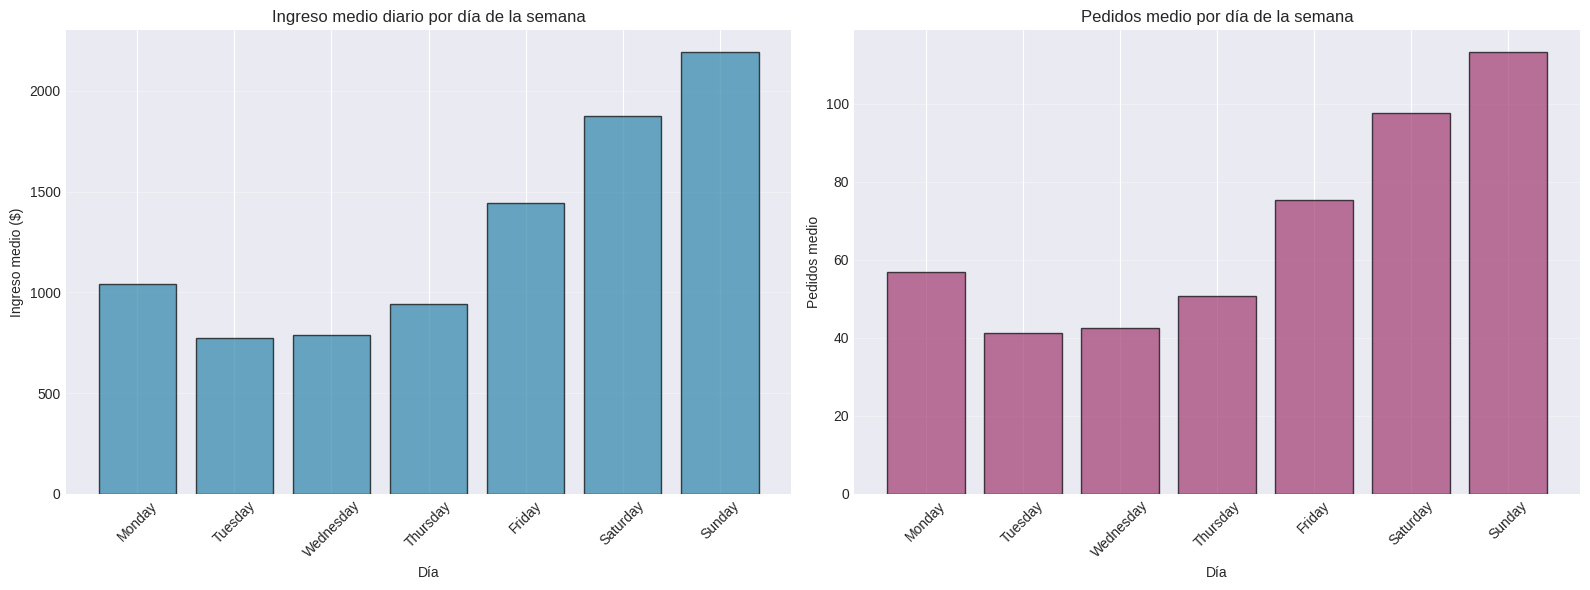

In [7]:
dia_semana_stats = ingresos_diarios.groupby('dia_semana').agg(
    {
        'ingresos_totales': ['mean', 'sum'],
        'cantidad_pedidos': ['mean', 'sum'],
        'promedio_pedido': 'mean',
    }
).reset_index()
dia_semana_stats.columns = [
    'dia_semana',
    'ingresos_promedio',
    'ingresos_totales',
    'pedidos_promedio',
    'pedidos_totales',
    'promedio_pedido',
]

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dia_semana_stats['dia_orden'] = pd.Categorical(
    dia_semana_stats['dia_semana'], categories=day_order, ordered=True
)
dia_semana_stats = dia_semana_stats.sort_values('dia_orden')

display(dia_semana_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(
    range(len(dia_semana_stats)),
    dia_semana_stats['ingresos_promedio'],
    color='#2E86AB',
    edgecolor='black',
    alpha=0.7,
)
axes[0].set_title('Ingreso medio diario por día de la semana', fontsize=12)
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Ingreso medio ($)')
axes[0].set_xticks(range(len(dia_semana_stats)))
axes[0].set_xticklabels(dia_semana_stats['dia_semana'], rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(
    range(len(dia_semana_stats)),
    dia_semana_stats['pedidos_promedio'],
    color='#A23B72',
    edgecolor='black',
    alpha=0.7,
)
axes[1].set_title('Pedidos medio por día de la semana', fontsize=12)
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Pedidos medio')
axes[1].set_xticks(range(len(dia_semana_stats)))
axes[1].set_xticklabels(dia_semana_stats['dia_semana'], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ingresos_por_dia_semana.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Ingresos por mes


,mes_nombre,ingresos_totales,cantidad_pedidos,promedio_pedido
0,2025-06,663.00,38,17.054167
1,2025-07,2524.97,160,15.227572
2,2025-08,16436.38,882,18.177802
3,2025-09,46973.45,2562,18.268322
4,2025-10,48068.25,2640,17.951810
5,2025-11,49431.00,2730,17.946606
6,2025-12,51925.40,2712,19.126032
7,2026-01,51570.44,2592,19.621097
8,2026-02,51798.14,2570,19.860001
9,2026-03,14324.75,696,19.863369


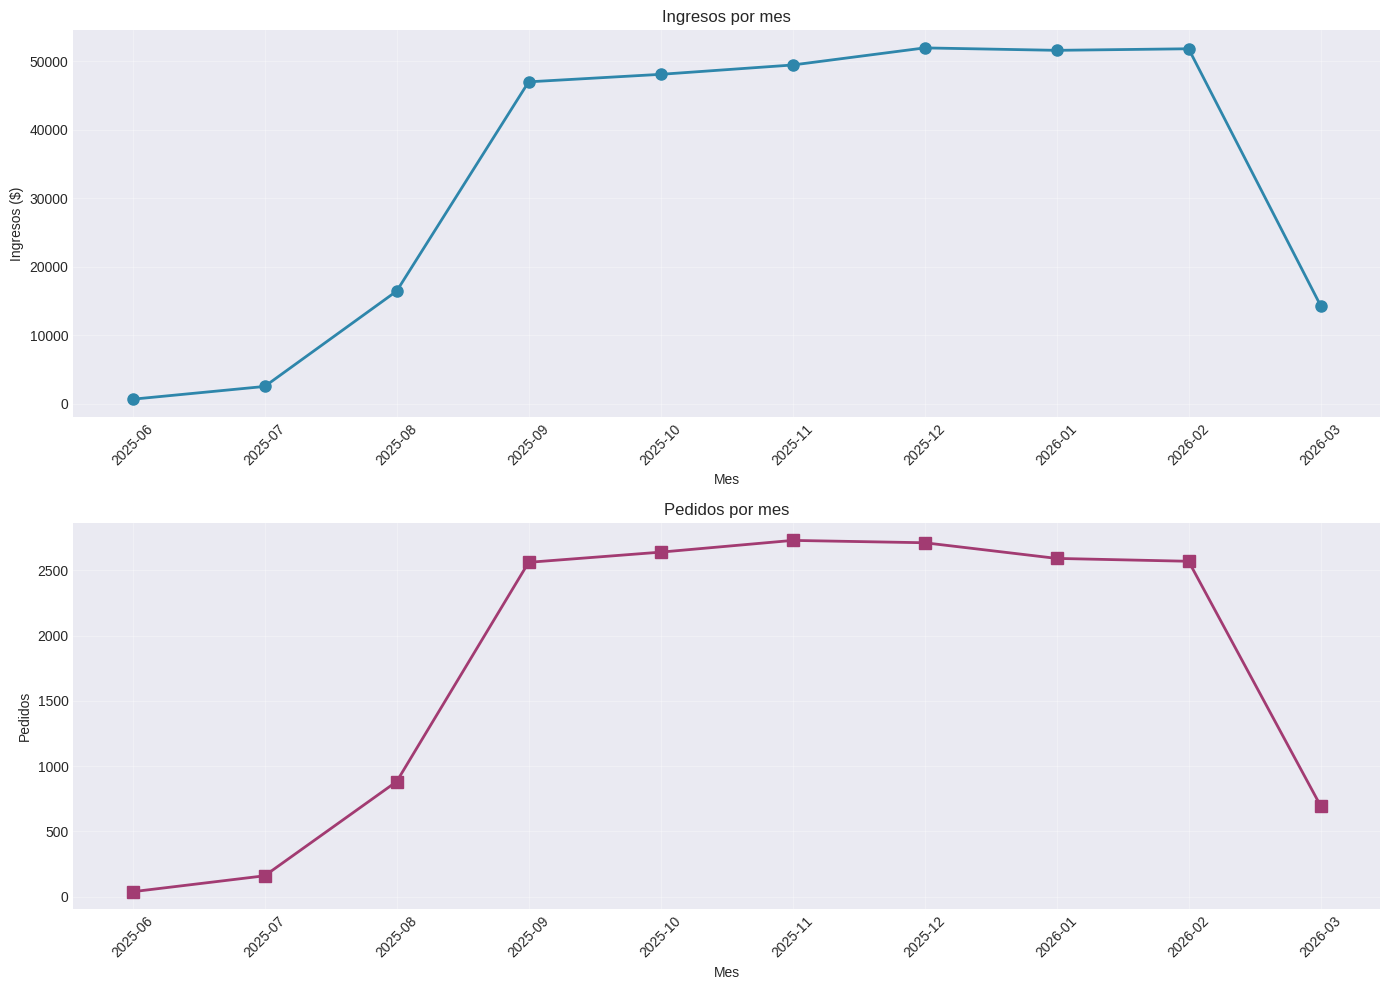

In [8]:
mes_stats = (
    ingresos_diarios.groupby(['año', 'mes'])
    .agg(
        {
            'ingresos_totales': 'sum',
            'cantidad_pedidos': 'sum',
            'promedio_pedido': 'mean',
        }
    )
    .reset_index()
)
mes_stats['mes_nombre'] = mes_stats.apply(
    lambda row: f"{int(row['año'])}-{int(row['mes']):02d}", axis=1
)
mes_stats = mes_stats.sort_values(['año', 'mes'])

display(mes_stats[['mes_nombre', 'ingresos_totales', 'cantidad_pedidos', 'promedio_pedido']])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(
    mes_stats['mes_nombre'],
    mes_stats['ingresos_totales'],
    marker='o',
    linewidth=2,
    markersize=8,
    color='#2E86AB',
)
axes[0].set_title('Ingresos por mes', fontsize=12)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ingresos ($)')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(
    mes_stats['mes_nombre'],
    mes_stats['cantidad_pedidos'],
    marker='s',
    linewidth=2,
    markersize=8,
    color='#A23B72',
)
axes[1].set_title('Pedidos por mes', fontsize=12)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Pedidos')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('tendencia_mensual_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Fin de semana y festivo


ingresos_totales                     cantidad_pedidos        \
                          mean        sum      std             mean   sum   
es_fin_semana                                                               
No                      995.66  183202.10   649.53            53.19  9787   
Sí                     2033.97  150513.68  1123.54           105.34  7795   

              promedio_pedido  
                         mean  
es_fin_semana                  
No                      18.02  
Sí                      18.87

ingresos_totales                    cantidad_pedidos         \
                       mean        sum     std             mean    sum   
es_festivo                                                               
No                  1286.12  316385.24  937.26            68.01  16730   
Sí                  1444.21   17330.54  988.36            71.00    852   

           promedio_pedido  
                      mean  
es_festivo                  
No                   18.20  
Sí                   19.74

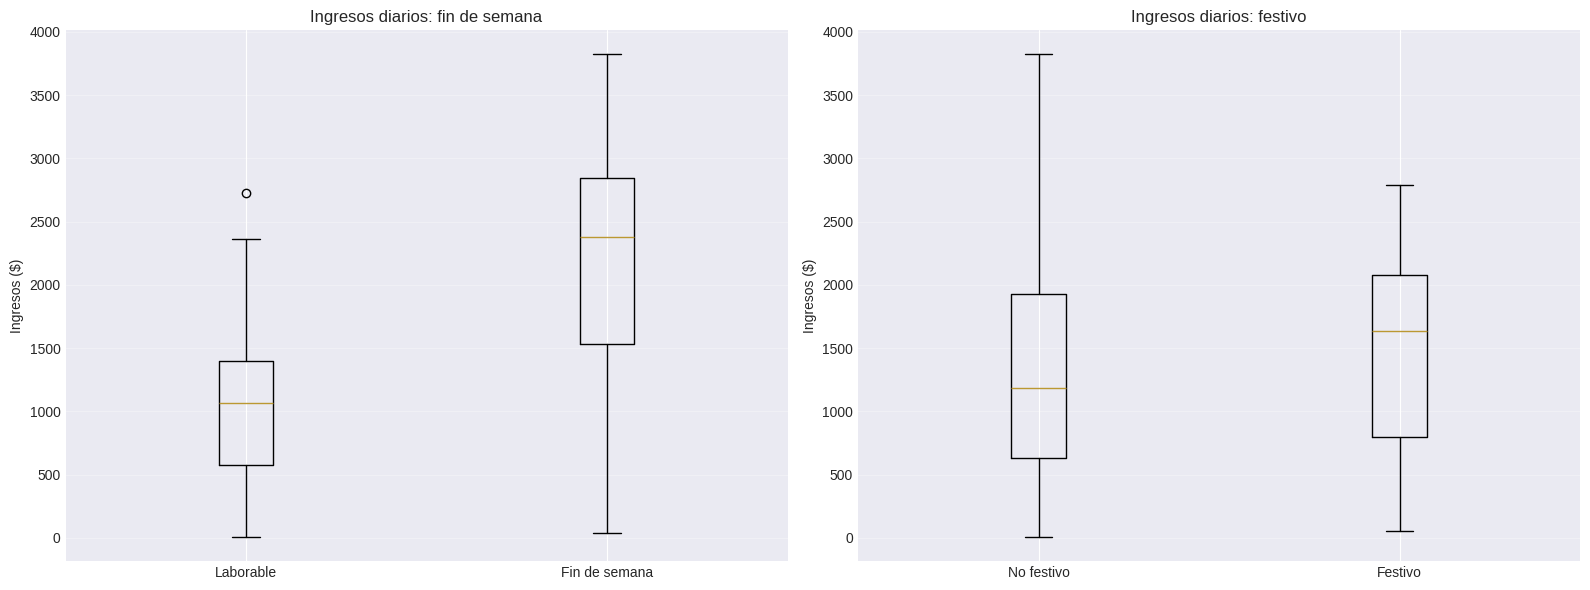

In [9]:
fin_semana_stats = (
    ingresos_diarios.groupby('es_fin_semana')
    .agg(
        {
            'ingresos_totales': ['mean', 'sum', 'std'],
            'cantidad_pedidos': ['mean', 'sum'],
            'promedio_pedido': 'mean',
        }
    )
    .round(2)
)
festivo_stats = (
    ingresos_diarios.groupby('es_festivo')
    .agg(
        {
            'ingresos_totales': ['mean', 'sum', 'std'],
            'cantidad_pedidos': ['mean', 'sum'],
            'promedio_pedido': 'mean',
        }
    )
    .round(2)
)
display(fin_semana_stats)
display(festivo_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fin_semana_data = [
    ingresos_diarios[ingresos_diarios['es_fin_semana'] == 'No']['ingresos_totales'].values,
    ingresos_diarios[ingresos_diarios['es_fin_semana'] == 'Sí']['ingresos_totales'].values,
]
axes[0].boxplot(fin_semana_data, labels=['Laborable', 'Fin de semana'])
axes[0].set_title('Ingresos diarios: fin de semana', fontsize=12)
axes[0].set_ylabel('Ingresos ($)')
axes[0].grid(True, alpha=0.3, axis='y')

festivo_data = [
    ingresos_diarios[ingresos_diarios['es_festivo'] == 'No']['ingresos_totales'].values,
    ingresos_diarios[ingresos_diarios['es_festivo'] == 'Sí']['ingresos_totales'].values,
]
axes[1].boxplot(festivo_data, labels=['No festivo', 'Festivo'])
axes[1].set_title('Ingresos diarios: festivo', fontsize=12)
axes[1].set_ylabel('Ingresos ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('festivos_fin_semana.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Serie diaria y distribución por día


,ingresos_dia
count,258.000000
mean,1293.472016
std,938.273620
min,7.500000
25%,634.200000
50%,1192.925000
75%,1963.120000
max,3821.310000


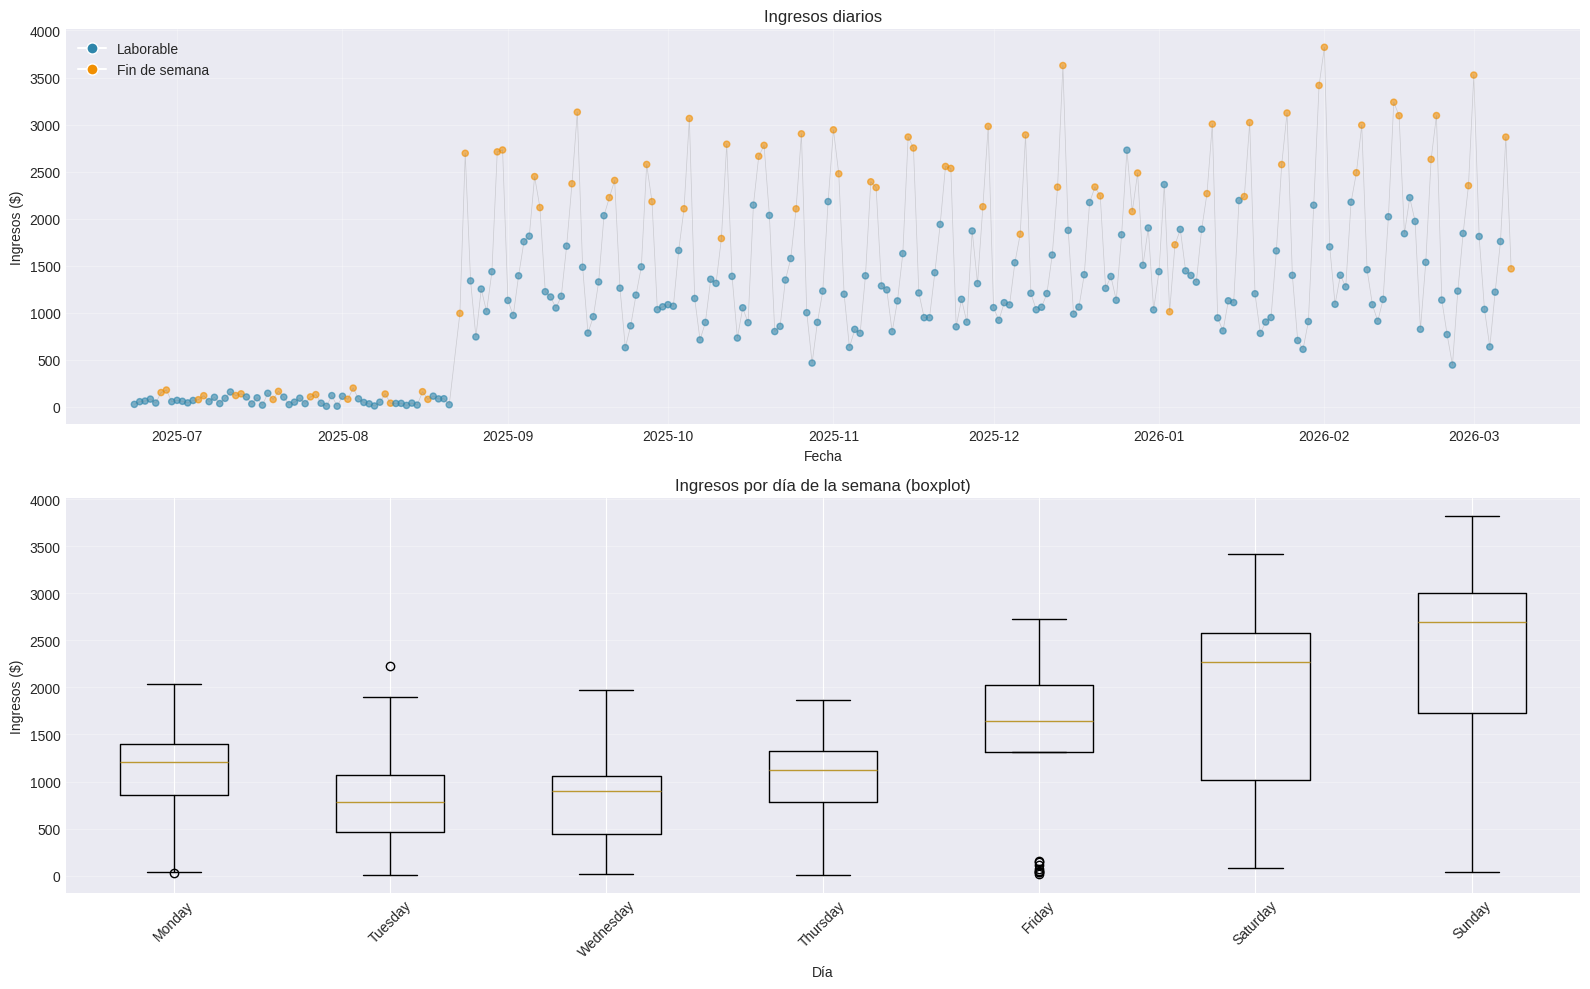

In [10]:
from matplotlib.lines import Line2D

ingresos_diarios = ingresos_diarios.sort_values('fecha')

display(ingresos_diarios['ingresos_totales'].describe().to_frame('ingresos_dia'))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

colors = ['#2E86AB' if x == 'No' else '#F18F01' for x in ingresos_diarios['es_fin_semana']]
axes[0].scatter(
    ingresos_diarios['fecha'],
    ingresos_diarios['ingresos_totales'],
    c=colors,
    alpha=0.6,
    s=20,
)
axes[0].plot(
    ingresos_diarios['fecha'],
    ingresos_diarios['ingresos_totales'],
    linewidth=0.5,
    alpha=0.3,
    color='gray',
)
axes[0].set_title('Ingresos diarios', fontsize=12)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Ingresos ($)')
axes[0].grid(True, alpha=0.3)
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E86AB', markersize=8, label='Laborable'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F18F01', markersize=8, label='Fin de semana'),
]
axes[0].legend(handles=legend_elems)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ingresos_diarios['dia_orden'] = pd.Categorical(
    ingresos_diarios['dia_semana'], categories=day_order, ordered=True
)
ingresos_ordenados = ingresos_diarios.sort_values('dia_orden')
box_data = [
    ingresos_ordenados[ingresos_ordenados['dia_semana'] == day]['ingresos_totales'].values
    for day in day_order
]
axes[1].boxplot(box_data, labels=day_order)
axes[1].set_title('Ingresos por día de la semana (boxplot)', fontsize=12)
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Ingresos ($)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('tendencias_estacionalidad.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Hora pico (modal por día)


,hora_mayor_ingreso_medio,ingreso_medio_en_esa_hora
0,23,1584.271839


,hora,ingresos_promedio,pedidos_promedio
0,0,1363.238699,71.926829
1,1,805.113333,41.333333
2,2,417.843333,20.666667
3,17,23.900000,3.000000
4,20,81.100000,6.000000
5,21,120.000000,7.000000
6,22,332.612000,18.866667
7,23,1584.271839,83.425287


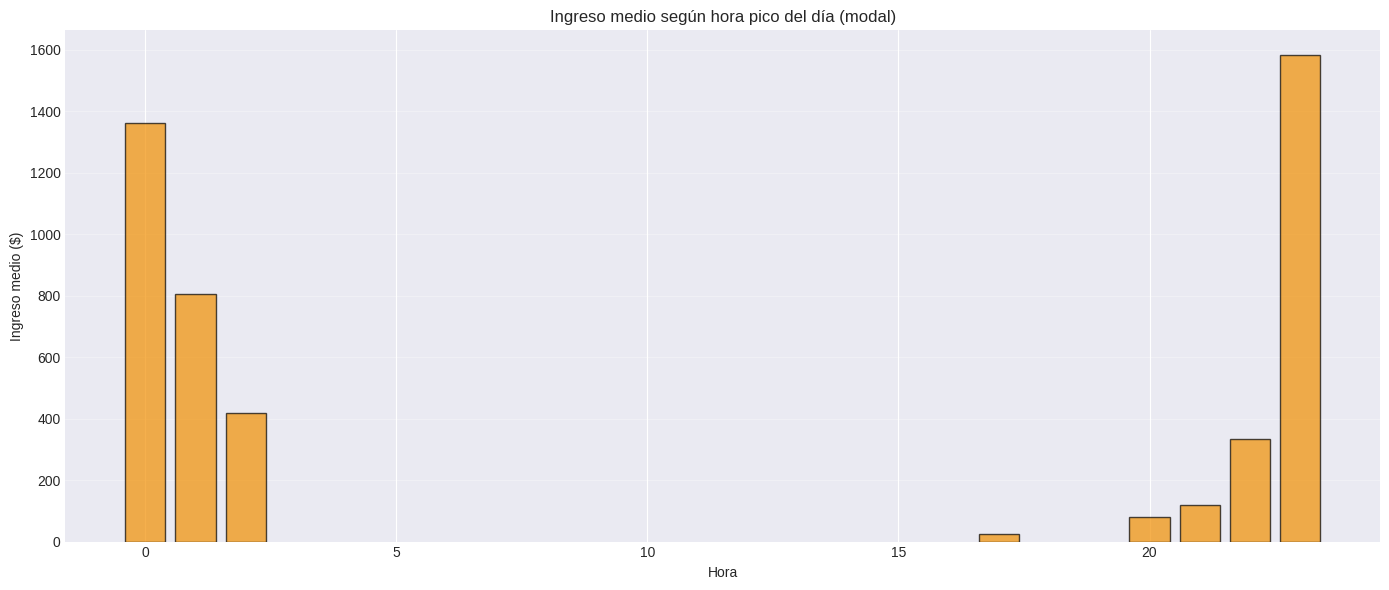

In [11]:
hora_pico_stats = ingresos_diarios.groupby('hora_pico_demanda').agg(
    {'ingresos_totales': 'mean', 'cantidad_pedidos': 'mean'}
).reset_index()
hora_pico_stats.columns = ['hora', 'ingresos_promedio', 'pedidos_promedio']
hora_pico_stats = hora_pico_stats.sort_values('hora')

idx = hora_pico_stats['ingresos_promedio'].idxmax()
display(
    pd.DataFrame(
        {
            'hora_mayor_ingreso_medio': [int(hora_pico_stats.loc[idx, 'hora'])],
            'ingreso_medio_en_esa_hora': [float(hora_pico_stats['ingresos_promedio'].max())],
        }
    )
)
display(hora_pico_stats)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.bar(
    hora_pico_stats['hora'],
    hora_pico_stats['ingresos_promedio'],
    color='#F18F01',
    edgecolor='black',
    alpha=0.7,
    width=0.8,
)
ax.set_title('Ingreso medio según hora pico del día (modal)', fontsize=12)
ax.set_xlabel('Hora')
ax.set_ylabel('Ingreso medio ($)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('horas_pico.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Correlaciones


,mes,dia_semana_num,es_festivo_num,es_fin_semana_num,promociones_activas,cantidad_pedidos,promedio_pedido,hora_pico_demanda,ingresos_totales
mes,1.000,-0.022,0.013,-0.010,NaN,0.020,-0.140,0.002,-0.037
dia_semana_num,-0.022,1.000,-0.036,0.793,NaN,0.475,0.104,0.211,0.482
es_festivo_num,0.013,-0.036,1.000,-0.018,NaN,0.013,0.097,-0.034,0.036
es_fin_semana_num,-0.010,0.793,-0.018,1.000,NaN,0.498,0.114,-0.002,0.501
promociones_activas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad_pedidos,0.020,0.475,0.013,0.498,NaN,1.000,0.305,0.071,0.989
promedio_pedido,-0.140,0.104,0.097,0.114,NaN,0.305,1.000,-0.083,0.370
hora_pico_demanda,0.002,0.211,-0.034,-0.002,NaN,0.071,-0.083,1.000,0.066
ingresos_totales,-0.037,0.482,0.036,0.501,NaN,0.989,0.370,0.066,1.000


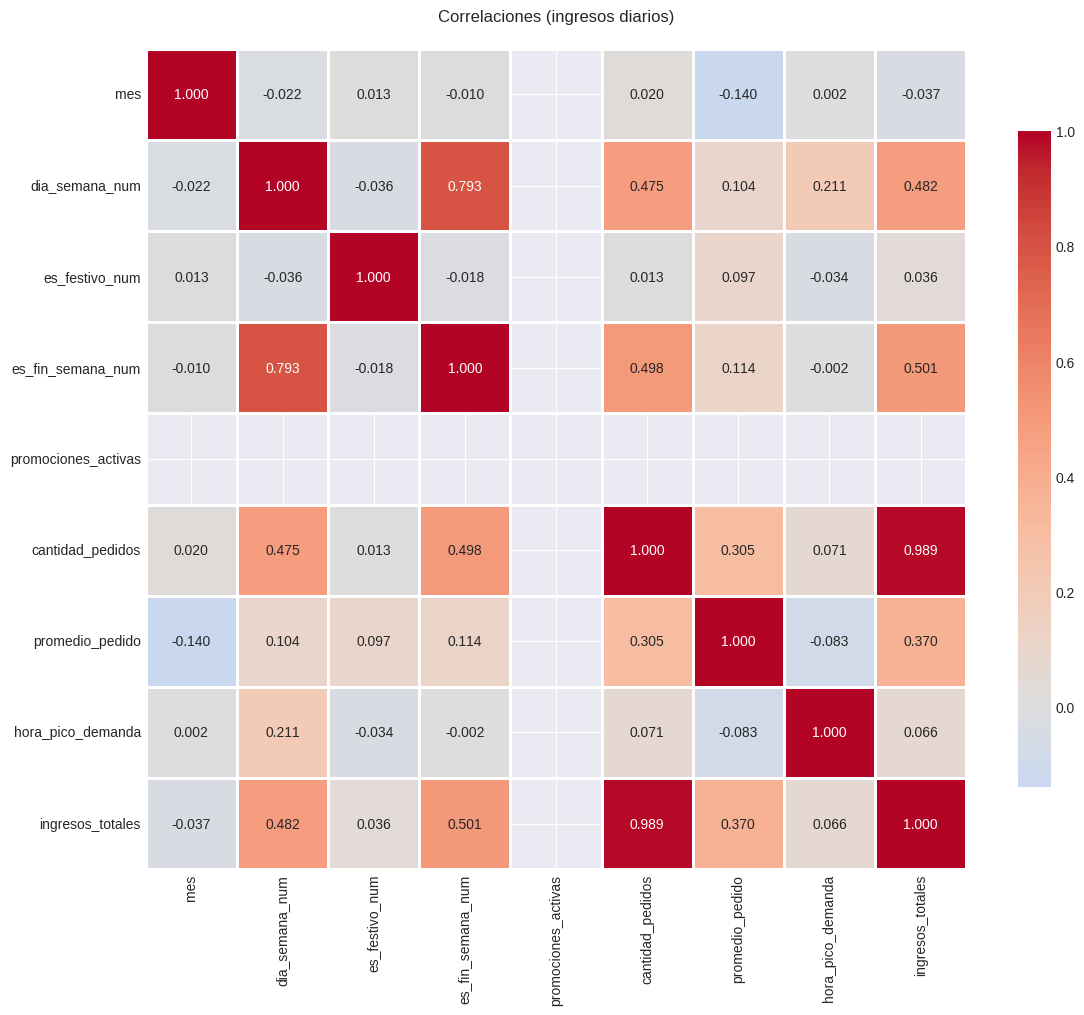

In [12]:
corr_data = ingresos_diarios.copy()

corr_data['dia_semana_num'] = corr_data['dia_semana'].map(
    {
        'Monday': 1,
        'Tuesday': 2,
        'Wednesday': 3,
        'Thursday': 4,
        'Friday': 5,
        'Saturday': 6,
        'Sunday': 7,
    }
)
corr_data['es_festivo_num'] = corr_data['es_festivo'].map({'Sí': 1, 'No': 0})
corr_data['es_fin_semana_num'] = corr_data['es_fin_semana'].map({'Sí': 1, 'No': 0})

corr_vars = [
    'mes',
    'dia_semana_num',
    'es_festivo_num',
    'es_fin_semana_num',
    'promociones_activas',
    'cantidad_pedidos',
    'promedio_pedido',
    'hora_pico_demanda',
    'ingresos_totales',
]
corr_matrix = corr_data[corr_vars].corr()

display(corr_matrix.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={'shrink': 0.8},
)
plt.title('Correlaciones (ingresos diarios)', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('matriz_correlaciones_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. CSV para modelado

Se exporta `datos_ingresos_periodo_limpio.csv` en `data/`.

In [13]:
dataset_modelado = ingresos_diarios[
    [
        'fecha',
        'ingresos_totales',
        'cantidad_pedidos',
        'dia_semana',
        'mes',
        'es_fin_semana',
        'es_festivo',
        'promociones_activas',
        'eventos_especiales',
        'promedio_pedido',
        'hora_pico_demanda',
    ]
].copy()

output_path = DATA_DIR / 'datos_ingresos_periodo_limpio.csv'
dataset_modelado.to_csv(output_path, index=False)

display(
    pd.DataFrame(
        {
            'filas': [len(dataset_modelado)],
            'columnas': [dataset_modelado.shape[1]],
            'fecha_min': [dataset_modelado['fecha'].min()],
            'fecha_max': [dataset_modelado['fecha'].max()],
            'ingresos_suma': [dataset_modelado['ingresos_totales'].sum()],
            'pedidos_suma': [dataset_modelado['cantidad_pedidos'].sum()],
            'archivo': [str(output_path)],
        }
    )
)
display(dataset_modelado.head(10))


,filas,columnas,fecha_min,fecha_max,ingresos_suma,pedidos_suma,archivo
0,258,11,2025-06-23,2026-03-08,333715.78,17582,data/datos_ingresos_periodo_limpio.csv


,fecha,ingresos_totales,cantidad_pedidos,dia_semana,mes,es_fin_semana,es_festivo,promociones_activas,eventos_especiales,promedio_pedido,hora_pico_demanda
0,2025-06-23,28.00,2,Monday,6,No,No,0,Normal,14.000000,22
1,2025-06-24,56.25,3,Tuesday,6,No,Sí,0,Normal,18.750000,0
2,2025-06-25,63.00,4,Wednesday,6,No,No,0,Normal,15.750000,0
3,2025-06-26,83.75,6,Thursday,6,No,No,0,Normal,13.958333,0
4,2025-06-27,42.00,3,Friday,6,No,No,0,Normal,14.000000,22
5,2025-06-28,153.25,5,Saturday,6,Sí,No,0,Normal,30.650000,0
6,2025-06-29,180.25,10,Sunday,6,Sí,No,0,Normal,18.025000,23
7,2025-06-30,56.50,5,Monday,6,No,No,0,Normal,11.300000,0
8,2025-07-01,70.50,5,Tuesday,7,No,No,0,Normal,14.100000,0
9,2025-07-02,60.50,5,Wednesday,7,No,No,0,Normal,12.100000,22
